# 02 — Feature Engineering

In [1]:
import sys
sys.path.insert(0, '..')   # so we can import from src/

# important packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# importing all functions from features.py file
from src.features import (build_box_features,
                          build_massey_features,
                          build_seed_features,
                          build_team_features,
                          build_matchup_df,
                          build_all)
# setting directories again
DATA_DIR  = Path('../data/raw')
PROC_DIR  = Path('../data/processed')

## 1. Build Per-Team Season Features

In [2]:
# Build and save both genders
team_feats = build_all(genders = ("M", "W"))

# split by gender
m_feats = team_feats["M"]
w_feats = team_feats["W"]

[M] Building box-score features...
[M] Building Massey ordinal features...
[M] Building seed features...
[M] Saved /Users/adamgold/Desktop/MM_26/data/processed/M_team_features.csv, shape = (8346, 23)
[W] Building box-score features...
[W] Building Massey ordinal features...
[W] Building seed features...
[W] Saved /Users/adamgold/Desktop/MM_26/data/processed/W_team_features.csv, shape = (5965, 19)


In [3]:
# checking Mensoutputs
print("\nMen's feature table:")
print(m_feats.shape)
print(m_feats.dtypes)
m_feats.head()


Men's feature table:
(8346, 23)
Season              int64
TeamID              int64
PointsFor         float64
PointsAgn         float64
WinPct            float64
ASTpg             float64
TOpg              float64
STLpg             float64
BLKpg             float64
FGpct             float64
FG3pct            float64
PointDiff         float64
eFG_pct           float64
TOV_pct           float64
ORB_pct           float64
FTR               float64
Def_eFG_pct       float64
rank_MAS          float64
rank_MOR          float64
rank_POM          float64
rank_composite    float64
SeedNum             int64
MadeTourney         int64
dtype: object


,Season,TeamID,PointsFor,PointsAgn,WinPct,ASTpg,TOpg,STLpg,BLKpg,FGpct,...,TOV_pct,ORB_pct,FTR,Def_eFG_pct,rank_MAS,rank_MOR,rank_POM,rank_composite,SeedNum,MadeTourney
0,2003,1102,57.250000,57.000000,0.428571,13.000000,11.428571,5.964286,1.785714,0.481149,...,0.194557,0.303109,0.280072,0.454545,172.0,132.0,160.0,154.666667,99,0
1,2003,1103,78.777778,78.148148,0.481481,15.222222,12.629630,7.259259,2.333333,0.486074,...,0.158154,0.448217,0.340849,0.487329,163.0,139.0,163.0,155.000000,99,0
2,2003,1104,69.285714,65.000000,0.607143,12.107143,13.285714,6.607143,3.785714,0.420362,...,0.166753,0.554745,0.259838,0.418919,41.0,26.0,33.0,33.333333,10,1
3,2003,1105,71.769231,76.653846,0.269231,14.538462,18.653846,9.307692,2.076923,0.395755,...,0.207538,0.505764,0.250312,0.457926,310.0,309.0,307.0,308.666667,99,0
4,2003,1106,63.607143,63.750000,0.464286,11.678571,17.035714,8.357143,3.142857,0.423773,...,0.214109,0.520424,0.192506,0.406689,270.0,294.0,263.0,275.666667,99,0


In [4]:
# Checking women's outputs
print("Women's feature table:")
print(w_feats.shape)
w_feats.head()

Women's feature table:
(5965, 19)


,Season,TeamID,PointsFor,PointsAgn,WinPct,ASTpg,TOpg,STLpg,BLKpg,FGpct,FG3pct,PointDiff,eFG_pct,TOV_pct,ORB_pct,FTR,Def_eFG_pct,SeedNum,MadeTourney
0,2010,3102,51.821429,71.785714,0.035714,10.250000,17.714286,6.035714,0.642857,0.360215,0.284444,-19.964286,0.403226,0.231042,0.492938,0.168683,0.478784,99,0
1,2010,3103,62.233333,59.633333,0.566667,13.433333,18.266667,8.033333,2.400000,0.402292,0.315508,2.600000,0.437877,0.222338,0.510180,0.250302,0.381443,99,0
2,2010,3104,64.137931,67.000000,0.379310,13.103448,19.172414,7.379310,2.931034,0.398112,0.295082,-2.862069,0.433093,0.216235,0.493537,0.166574,0.397362,99,0
3,2010,3105,60.777778,64.740741,0.518519,9.740741,25.037037,8.777778,5.148148,0.400583,0.307116,-3.962963,0.430444,0.289126,0.473684,0.334304,0.396008,99,0
4,2010,3106,55.137931,57.413793,0.413793,11.482759,20.103448,8.034483,4.482759,0.348081,0.280576,-2.275862,0.373455,0.240290,0.547859,0.293429,0.353061,99,0


In [5]:
# Check for missingness
print("=== Men's Missing Value Summary ===")
miss = m_feats.isnull().mean().sort_values(ascending = False)
print(miss[miss > 0])

print("\n=== Women's Missing Value Summary ===")
miss_w = w_feats.isnull().mean().sort_values(ascending = False)
print(miss_w[miss_w > 0])

=== Men's Missing Value Summary ===
rank_MAS          0.162832
rank_POM          0.000479
rank_composite    0.000120
rank_MOR          0.000120
dtype: float64

=== Women's Missing Value Summary ===
Series([], dtype: float64)


## 2. Inspect Key Feature Distributions

For tournament teams only

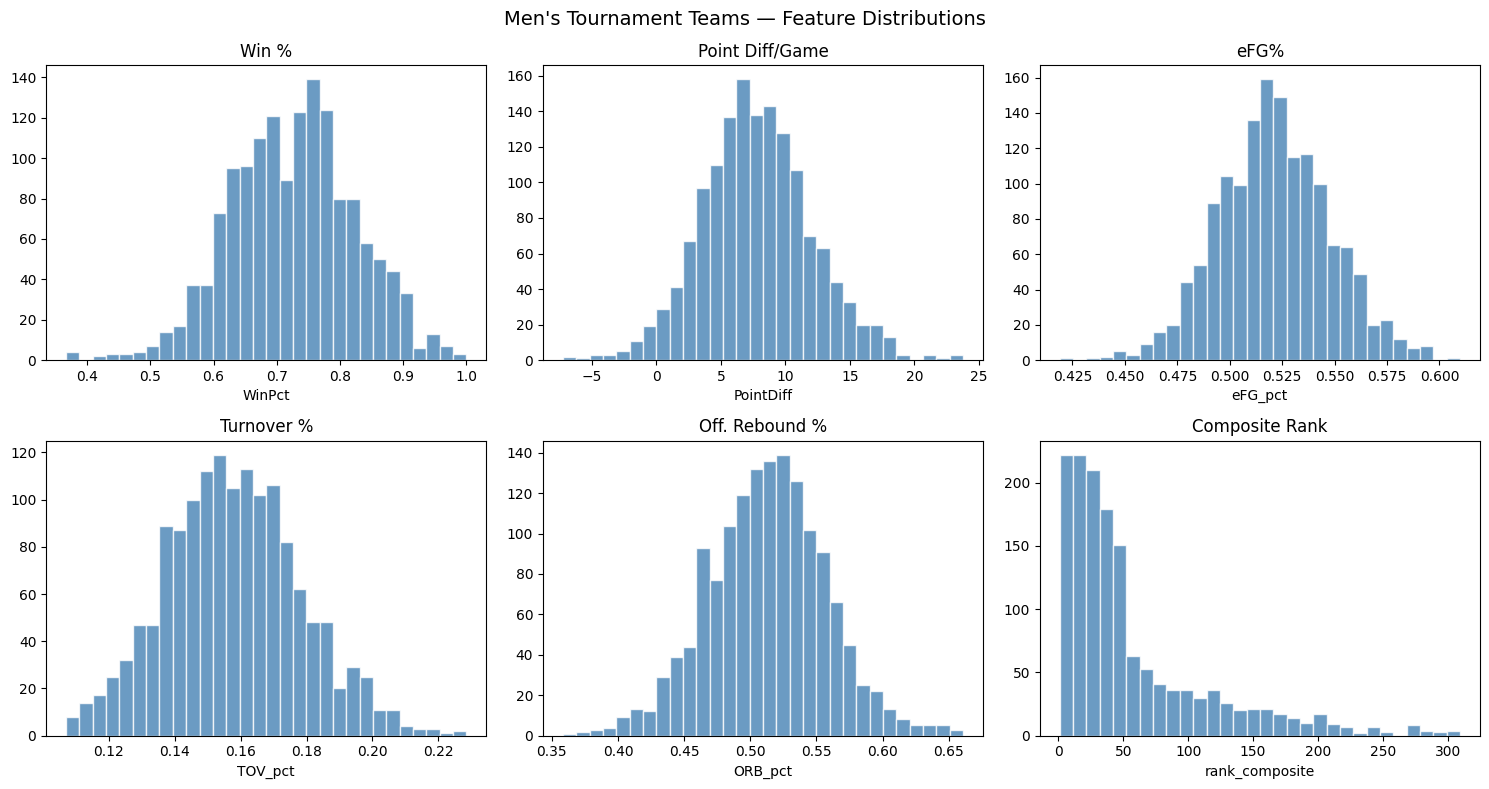

In [6]:
# Filter to tournament teams only for plotting
m_tourney_teams = m_feats[m_feats['MadeTourney'] == 1].copy()

fig, axes = plt.subplots(2, 3, figsize = (15, 8))
fig.suptitle("Men's Tournament Teams — Feature Distributions", fontsize = 14)

plot_cols = ['WinPct', 'PointDiff', 'eFG_pct', 'TOV_pct', 'ORB_pct', 'rank_composite']
titles = ['Win %', 'Point Diff/Game', 'eFG%', 'Turnover %', 'Off. Rebound %', 'Composite Rank']

for ax, col, title in zip(axes.flat, plot_cols, titles):
    data = m_tourney_teams[col].dropna()
    ax.hist(data, bins = 30, color = 'steelblue', edgecolor = 'white', alpha = 0.8)
    ax.set_title(title)
    ax.set_xlabel(col)

plt.tight_layout()
#plt.savefig('../outputs/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Build Matchup-Level Training Dataset

Each row = one historical tournament game.
Features = Team A stats **minus** Team B stats (relative strength).
Label = 1 if Team A (lower ID) won, 0 if Team B won.

In [7]:
# m_feats.isna().sum()

In [8]:
# using previous years seeding from tournament
m_train, m_diff_cols = build_matchup_df(m_feats, gender = "M", mode = "train")
w_train, w_diff_cols = build_matchup_df(w_feats, gender = "W", mode = "train")

print("\nMen's training matchups:", m_train.shape)
print("Women's training matchups:", w_train.shape)
print("\nLabel distribution (men):")
print(m_train['Label'].value_counts())
print("\nDiff features available:", m_diff_cols)

[M] Matchup df shape: (1449, 61)  |  diff features: 19
[W] Matchup df shape: (961, 52)  |  diff features: 16

Men's training matchups: (1449, 61)
Women's training matchups: (961, 52)

Label distribution (men):
Label
1    725
0    724
Name: count, dtype: int64

Diff features available: ['diff_PointsFor', 'diff_PointsAgn', 'diff_WinPct', 'diff_ASTpg', 'diff_TOpg', 'diff_STLpg', 'diff_BLKpg', 'diff_FGpct', 'diff_FG3pct', 'diff_PointDiff', 'diff_eFG_pct', 'diff_TOV_pct', 'diff_ORB_pct', 'diff_FTR', 'diff_Def_eFG_pct', 'diff_rank_MAS', 'diff_rank_MOR', 'diff_rank_POM', 'diff_SeedNum']


In [9]:
# # print(m_train.shape)
# print(m_train.isna().sum())

# # print(m_train.dropna().head())

In [10]:
m_train.head(5)

,Season,TeamA,TeamB,Label,A_PointsFor,A_PointsAgn,A_WinPct,A_ASTpg,A_TOpg,A_STLpg,...,diff_PointDiff,diff_eFG_pct,diff_TOV_pct,diff_ORB_pct,diff_FTR,diff_Def_eFG_pct,diff_rank_MAS,diff_rank_MOR,diff_rank_POM,diff_SeedNum
0,2003,1411,1421,0,72.800000,70.833333,0.600000,14.200000,15.233333,6.433333,...,9.208046,0.014867,-0.013273,0.052420,0.033720,-0.030938,-16.0,16.0,-5.0,0
1,2003,1112,1436,1,85.214286,70.250000,0.892857,17.642857,14.785714,8.464286,...,10.309113,0.023279,-0.017553,-0.038307,0.036601,-0.005765,-145.0,-183.0,-141.0,-15
2,2003,1113,1272,1,75.965517,69.172414,0.620690,15.551724,14.000000,5.206897,...,-1.896552,0.017069,0.005383,0.021832,0.059060,0.043212,22.0,-1.0,12.0,3
3,2003,1141,1166,1,79.344828,73.241379,0.793103,15.620690,18.241379,7.103448,...,-8.805643,0.001197,0.054619,-0.032110,0.124277,0.023218,17.0,17.0,23.0,5
4,2003,1143,1301,1,74.482759,69.758621,0.724138,16.000000,14.172414,6.551724,...,0.324138,-0.010679,-0.011599,0.021275,-0.067792,-0.009357,-18.0,12.0,-8.0,-1


## 4. Correlation of Features with Outcome

Which difference features are most predictive of winning?

In [11]:
# Point-biserial correlation of each diff feature with Label
correlations = {}
for col in m_diff_cols:
    valid = m_train[[col, 'Label']].dropna()
    if len(valid) > 50:
        correlations[col] = valid[col].corr(valid['Label'])

corr_series = pd.Series(correlations).sort_values(key = abs, ascending = False)

print("Top 15 features by correlation with outcome:")
print(corr_series.head(15).to_string())

Top 15 features by correlation with outcome:
diff_SeedNum       -0.482353
diff_rank_MOR      -0.455381
diff_rank_POM      -0.450900
diff_rank_MAS      -0.432449
diff_PointDiff      0.405514
diff_WinPct         0.325598
diff_PointsFor      0.233230
diff_TOV_pct       -0.219902
diff_Def_eFG_pct   -0.207849
diff_ASTpg          0.207149
diff_FGpct          0.203164
diff_BLKpg          0.202383
diff_eFG_pct        0.181139
diff_TOpg          -0.154805
diff_PointsAgn     -0.149082


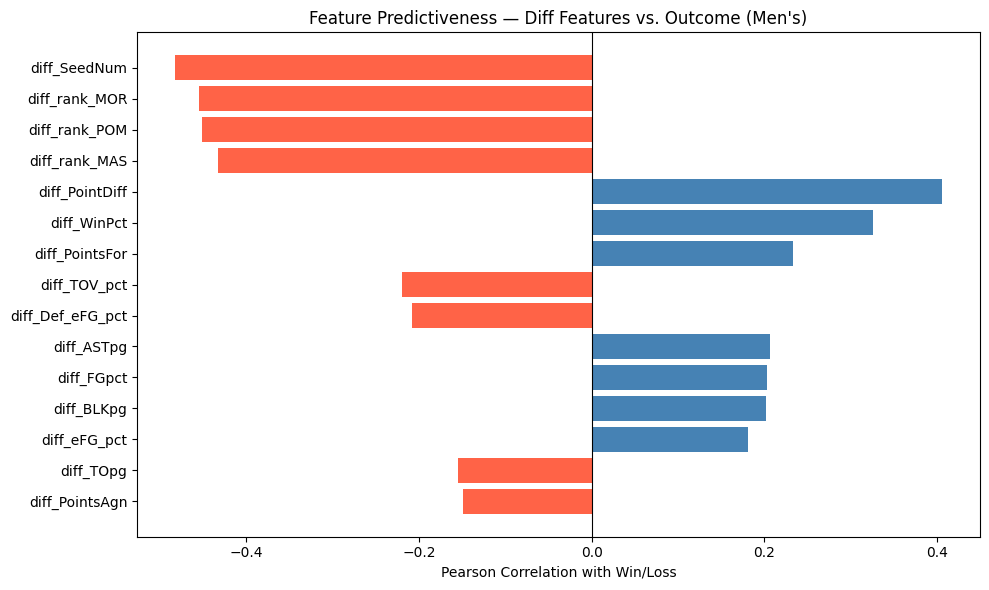

In [12]:
# Visualise top 15
top15 = corr_series.head(15)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in top15.values]
plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth = 0.8)
plt.xlabel('Pearson Correlation with Win/Loss')
plt.title("Feature Predictiveness — Diff Features vs. Outcome (Men's)")
plt.tight_layout()
plt.show()


## 5. Save Training Datasets

In [13]:
# Save training matchup DataFrames
m_train.to_csv(PROC_DIR / 'M_matchup_train.csv', index=False)
w_train.to_csv(PROC_DIR / 'W_matchup_train.csv', index=False)

# Save the diff column names so the model notebook can reference them
import json
with open(PROC_DIR / 'M_diff_cols.json', 'w') as f:
    json.dump(m_diff_cols, f)
with open(PROC_DIR / 'W_diff_cols.json', 'w') as f:
    json.dump(w_diff_cols, f)

print("Saved:")
print(" data/processed/M_matchup_train.csv")
print(" data/processed/W_matchup_train.csv")
print(" data/processed/M_diff_cols.json")
print(" data/processed/W_diff_cols.json")

Saved:
 data/processed/M_matchup_train.csv
 data/processed/W_matchup_train.csv
 data/processed/M_diff_cols.json
 data/processed/W_diff_cols.json


## 6. Build Prediction (Stage 2) Datasets

These are the 2026 matchups we need to submit probabilities for.

In [14]:
m_pred, _ = build_matchup_df(m_feats, gender = "M", mode = "predict")
w_pred, _ = build_matchup_df(w_feats, gender = "W", mode = "predict")

print("Men's 2026 prediction matchups:", m_pred.shape)
print("Women's 2026 prediction matchups:", w_pred.shape)

# pretty much just taking the sample submission 2 file and saving it as my own
m_pred.to_csv(PROC_DIR / 'M_matchup_predict.csv', index = False)
w_pred.to_csv(PROC_DIR / 'W_matchup_predict.csv', index = False)
print("\nSaved prediction datasets.")

[M] Matchup df shape: (66430, 62)  |  diff features: 19
[W] Matchup df shape: (65703, 53)  |  diff features: 16
Men's 2026 prediction matchups: (66430, 62)
Women's 2026 prediction matchups: (65703, 53)

Saved prediction datasets.


In [15]:
# Sanity check: how many 2026 matchups have missing features?
print("Missing diff features in 2026 men's prediction set:")
diff_cols_pred = [c for c in m_pred.columns if c.startswith('diff_')]
miss = m_pred[diff_cols_pred].isnull().mean().sort_values(ascending = False)
print(miss[miss > 0].head(10))

Missing diff features in 2026 men's prediction set:
Series([], dtype: float64)


## Summary

| | Men's | Women's |
|---|---|---|
| Team-season rows | | |
| Diff features | | |
| Training matchups | | |
| 2026 prediction matchups | | |

**Key findings from correlation analysis:**
- (fill in after running — which features rank highest?)

**Next:** `03_model.ipynb` — train a logistic regression baseline, then a PyTorch neural network, validate on 2022–2025 holdout.